N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, erg/Eb=0.964113646212 Variance=5.7360118938e-01
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.270698, erg/Eb=0.977394393590 Variance=1.1937537964e+00
N= 6, τ=0.4344, Eb=3.629996, Ergotropy=3.569077, erg/Eb=0.983217938503 Variance=1.8187603488e+00
N= 8, τ=0.3835, Eb=4.959031, Ergotropy=4.892299, erg/Eb=0.986543302995 Variance=2.4458199751e+00
N=10, τ=0.3478, Eb=6.304397, Ergotropy=6.233174, erg/Eb=0.988702729484 Variance=3.0741384917e+00
N=12, τ=0.3208, Eb=7.659302, Ergotropy=7.584551, erg/Eb=0.990240531747 Variance=3.7029764151e+00
N=14, τ=0.2996, Eb=9.026205, Ergotropy=8.948379, erg/Eb=0.991377821396 Variance=4.3325546580e+00
N=16, τ=0.2823, Eb=10.401140, Ergotropy=10.320660, erg/Eb=0.992262308900 Variance=4.9624898318e+00
N=18, τ=0.2678, Eb=11.781979, Ergotropy=11.699193, erg/Eb=0.992973520367 Variance=5.5926167902e+00
N=20, τ=0.2555, Eb=13.172037, Ergotropy=13.087090, erg/Eb=0.993550934314 Variance=6.2231777395e+00
N=22, τ=0.2448, Eb=14.56

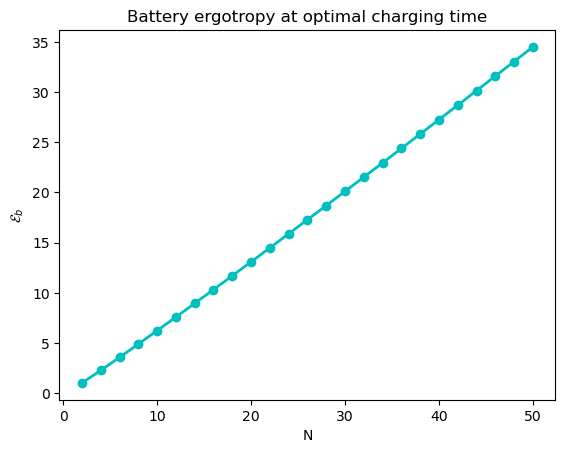

In [6]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 9, 1)
nmax = 350
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
        
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j] for j in range(len(r_vals)))

    W_2 = (qt.expect(HB**2, rho_b) + sum(r_vals[j]*(e_vals[j])**2 for j in range(len(r_vals)))) - 2 * sum(e_vals[i]*r_vals[i]*qt.expect(HB, r_vecs[i]) for i in range(len(r_vals)))
    
    ΔE2 = W_2 - (E_erg)**2
    
    ΔE = np.sqrt( ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)


    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

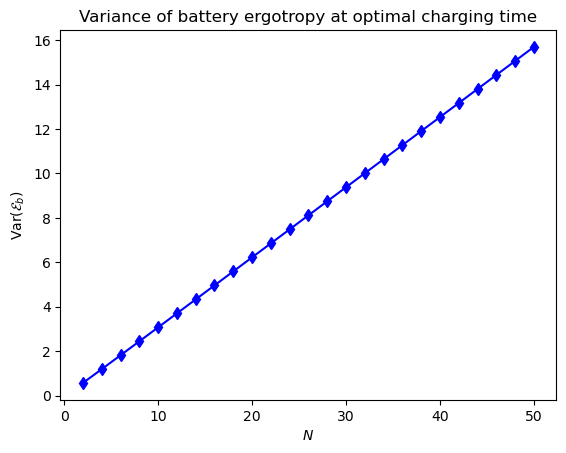

In [7]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

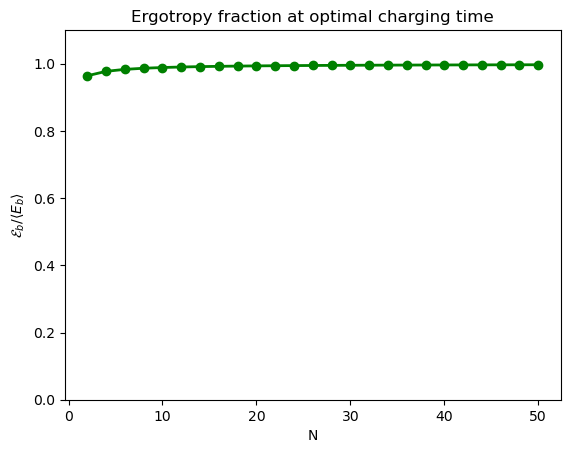

In [8]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.6822, Relative Fluctuation =0.742391851433, Relative Fluctuation with Eb =0.715750114803
N= 4, τ=0.5158, Relative Fluctuation =0.481169310551, Relative Fluctuation with Eb =0.470292186500
N= 6, τ=0.4344, Relative Fluctuation =0.377860774520, Relative Fluctuation with Eb =0.371519491765
N= 8, τ=0.3835, Relative Fluctuation =0.319668085506, Relative Fluctuation with Eb =0.315366408937
N=10, τ=0.3478, Relative Fluctuation =0.281288800747, Relative Fluctuation with Eb =0.278111005072
N=12, τ=0.3208, Relative Fluctuation =0.253714675415, Relative Fluctuation with Eb =0.251238555095
N=14, τ=0.2996, Relative Fluctuation =0.232609601996, Relative Fluctuation with Eb =0.230604000463
N=16, τ=0.2823, Relative Fluctuation =0.215845184027, Relative Fluctuation with Eb =0.214175040667
N=18, τ=0.2678, Relative Fluctuation =0.202139702006, Relative Fluctuation with Eb =0.200719371507
N=20, τ=0.2555, Relative Fluctuation =0.190617608640, Relative Fluctuation with Eb =0.189388303161
N=22, τ=0.

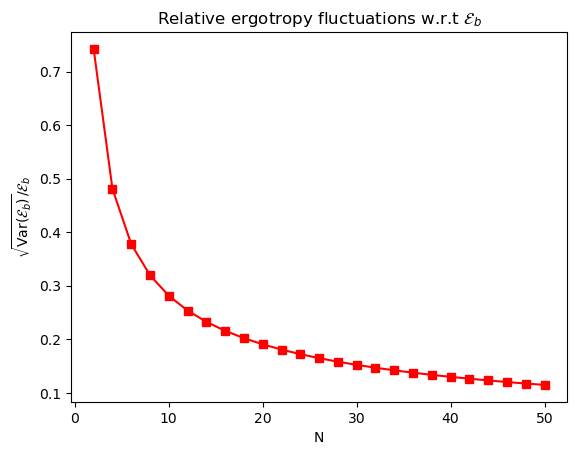

In [9]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

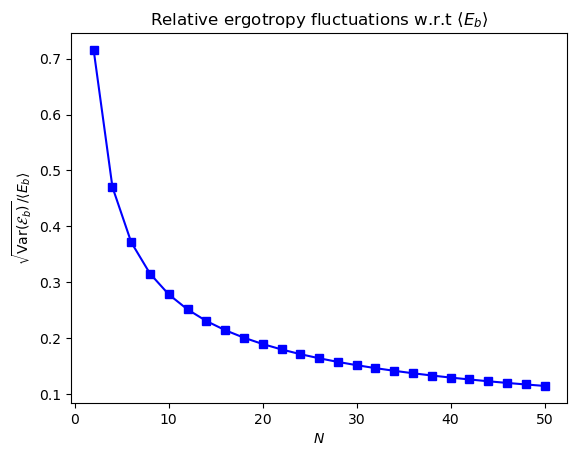

In [10]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()